**© Copyright AIDENTIFY. All rights reserved.**

# Part 1 | Session 2: 자연어 처리 기초 - 인코딩, 토큰화, 임베딩(Word2Vec)

---

이 노트북에서는 자연어 처리(NLP)의 기초가 되는 핵심 개념들을 학습합니다:

1. **텍스트 인코딩**: 컴퓨터가 문자를 이해하는 방법 (ASCII, UTF-8, Unicode)
2. **토큰화(Tokenization)**: 텍스트를 의미 단위로 분리하는 방법
3. **임베딩(Embedding)**: 단어를 벡터 공간에 표현하는 방법 (Word2Vec)
4. **현대 임베딩**: 문맥 기반 임베딩 간단 소개
5. **실습**: 한국어 텍스트로 직접 실습

## 환경 설정

필요한 패키지를 설치합니다.

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# !pip install -q transformers tokenizers gensim matplotlib scikit-learn numpy


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

---
## 1️⃣ 텍스트 인코딩 (Text Encoding)

컴퓨터는 숫자만 이해할 수 있습니다. 그래서 문자를 숫자로 변환하는 **인코딩(encoding)** 과정이 필요합니다.

### 주요 인코딩 방식

| 인코딩 | 설명 | 범위 |
|---------|------|------|
| **ASCII** | 7비트, 128개 문자 | 영어 + 기본 기호만 |
| **Unicode** | 전 세계 모든 문자에 고유 코드 포인트 부여 | 한글, 이모지 등 모두 포함 |
| **UTF-8** | 가변 길이 인코딩 (1~4바이트) | Unicode의 실제 저장/전송 방식 |

> **핵심**: Unicode는 문자와 코드 포인트의 **매핑 테이블**이고, UTF-8은 그 코드 포인트를 **바이트로 저장하는 방법**입니다.

In [3]:
# === ASCII 인코딩 ===
text_en = "Hello"
print("=== ASCII 인코딩 ===")
for ch in text_en:
    print(f"  '{ch}' -> ASCII: {ord(ch)}, 이진수: {bin(ord(ch))}")

print()

# === 한글은 ASCII로 인코딩 불가 ===
text_ko = "한글"
try:
    text_ko.encode('ascii')
except UnicodeEncodeError as e:
    print(f"한글 ASCII 인코딩 실패: {e}")

=== ASCII 인코딩 ===
  'H' -> ASCII: 72, 이진수: 0b1001000
  'e' -> ASCII: 101, 이진수: 0b1100101
  'l' -> ASCII: 108, 이진수: 0b1101100
  'l' -> ASCII: 108, 이진수: 0b1101100
  'o' -> ASCII: 111, 이진수: 0b1101111

한글 ASCII 인코딩 실패: 'ascii' codec can't encode characters in position 0-1: ordinal not in range(128)


In [4]:
# === Unicode 코드 포인트 확인 ===
text = "한글 NLP 시작!"
print("=== Unicode 코드 포인트 ===")
for ch in text:
    print(f"  '{ch}' -> U+{ord(ch):04X} (10진수: {ord(ch)})")

print()

# === UTF-8 인코딩: 문자마다 바이트 수가 다름 ===
print("=== UTF-8 인코딩 (바이트 단위) ===")
for ch in text:
    encoded = ch.encode('utf-8')
    hex_str = ' '.join(f'{b:02x}' for b in encoded)
    print(f"  '{ch}' -> {len(encoded)}바이트: [{hex_str}]")

print(f"\n전체 문자열 UTF-8 바이트 수: {len(text.encode('utf-8'))} bytes")
print(f"전체 문자 수 (len): {len(text)} 문자")

=== Unicode 코드 포인트 ===
  '한' -> U+D55C (10진수: 54620)
  '글' -> U+AE00 (10진수: 44544)
  ' ' -> U+0020 (10진수: 32)
  'N' -> U+004E (10진수: 78)
  'L' -> U+004C (10진수: 76)
  'P' -> U+0050 (10진수: 80)
  ' ' -> U+0020 (10진수: 32)
  '시' -> U+C2DC (10진수: 49884)
  '작' -> U+C791 (10진수: 51089)
  '!' -> U+0021 (10진수: 33)

=== UTF-8 인코딩 (바이트 단위) ===
  '한' -> 3바이트: [ed 95 9c]
  '글' -> 3바이트: [ea b8 80]
  ' ' -> 1바이트: [20]
  'N' -> 1바이트: [4e]
  'L' -> 1바이트: [4c]
  'P' -> 1바이트: [50]
  ' ' -> 1바이트: [20]
  '시' -> 3바이트: [ec 8b 9c]
  '작' -> 3바이트: [ec 9e 91]
  '!' -> 1바이트: [21]

전체 문자열 UTF-8 바이트 수: 18 bytes
전체 문자 수 (len): 10 문자


> **포인트**: 한글 한 글자는 UTF-8에서 **3바이트**를 차지합니다. 영어는 1바이트입니다. 이 차이가 LLM의 토큰 효율성에도 영향을 미칩니다.

---
## 2️⃣ 토큰화 (Tokenization)

**토큰화**란 텍스트를 모델이 처리할 수 있는 최소 단위(**토큰**)로 분리하는 과정입니다.

### 토큰화 전략 비교

| 방식 | 설명 | 예시 |
|------|------|------|
| **단어 단위** (Word-level) | 공백/구두점 기준 분리 | `["나는", "학생이다"]` |
| **서브워드** (Subword) | 자주 나오는 부분 단어로 분리 | `["나", "는", "학생", "이다"]` |
| **문자 단위** (Character-level) | 글자 하나씩 분리 | `["나", "는", "학", "생", ...]` |

### 서브워드 토큰화 알고리즘

- **BPE (Byte Pair Encoding)**: 가장 빈번한 문자 쌍을 반복적으로 병합 (GPT 계열)
- **WordPiece**: BPE와 유사하지만 우도(likelihood) 기반 병합 (BERT)
- **SentencePiece**: 언어 독립적, 공백도 토큰으로 처리 (T5, LLaMA)

In [5]:
# === 1. 단어 단위 토큰화 (가장 단순한 방법) ===
text = "자연어 처리는 인공지능의 핵심 분야입니다."

# 공백 기준 분리
word_tokens = text.split()
print("[단어 단위 토큰화]")
print(f"  원문: {text}")
print(f"  토큰: {word_tokens}")
print(f"  토큰 수: {len(word_tokens)}")

print()

# === 2. 문자 단위 토큰화 ===
char_tokens = list(text.replace(' ', ''))
print("[문자 단위 토큰화]")
print(f"  토큰: {char_tokens}")
print(f"  토큰 수: {len(char_tokens)}")

[단어 단위 토큰화]
  원문: 자연어 처리는 인공지능의 핵심 분야입니다.
  토큰: ['자연어', '처리는', '인공지능의', '핵심', '분야입니다.']
  토큰 수: 5

[문자 단위 토큰화]
  토큰: ['자', '연', '어', '처', '리', '는', '인', '공', '지', '능', '의', '핵', '심', '분', '야', '입', '니', '다', '.']
  토큰 수: 19


In [6]:
# === 3. 서브워드 토큰화: HuggingFace Transformers 사용 ===
from transformers import AutoTokenizer

text = "자연어 처리는 인공지능의 핵심 분야입니다."

# --- BERT (WordPiece) ---
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
bert_tokens = bert_tokenizer.tokenize(text)
bert_ids = bert_tokenizer.encode(text)

print("=== BERT (WordPiece) ===")
print(f"  토큰: {bert_tokens}")
print(f"  토큰 ID: {bert_ids}")
print(f"  토큰 수: {len(bert_tokens)}")
print()

=== BERT (WordPiece) ===
  토큰: ['자', '##연', '##어', '처', '##리는', '인', '##공', '##지', '##능', '##의', '핵', '##심', '분', '##야', '##입', '##니다', '.']
  토큰 ID: [101, 9651, 25486, 12965, 9744, 26344, 9640, 28000, 12508, 74986, 10459, 9961, 71013, 9367, 21711, 58303, 48345, 119, 102]
  토큰 수: 17



In [7]:
# --- GPT-2 (BPE) ---
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_tokens = gpt2_tokenizer.tokenize(text)
gpt2_ids = gpt2_tokenizer.encode(text)

print("=== GPT-2 (BPE) ===")
print(f"  토큰: {gpt2_tokens}")
print(f"  토큰 ID: {gpt2_ids}")
print(f"  토큰 수: {len(gpt2_tokens)}")
print()

# 토큰 수 비교
print("=== 토큰 수 비교 ===")
print(f"  BERT (WordPiece): {len(bert_tokens)}개")
print(f"  GPT-2 (BPE):     {len(gpt2_tokens)}개")
print("\n→ 한국어에 특화되지 않은 토크나이저는 토큰 수가 많아집니다!")

=== GPT-2 (BPE) ===
  토큰: ['ì', 'ŀ', 'Ĳ', 'ì', 'Ĺ', '°', 'ì', 'ĸ', '´', 'Ġì', '²', 'ĺ', 'ë', '¦', '¬', 'ë', 'Ĭ', 'Ķ', 'Ġì', 'Ŀ', '¸', 'ê', '³', 'µ', 'ì', '§', 'Ģ', 'ë', 'Ĭ', '¥', 'ìĿ', 'ĺ', 'Ġ', 'íķ', 'µ', 'ì', 'ĭ', '¬', 'Ġë', '¶', 'Ħ', 'ì', 'ķ', '¼', 'ì', 'ŀ', 'ħ', 'ëĭ', 'Ī', 'ëĭ', '¤', '.']
  토큰 ID: [168, 252, 238, 168, 245, 108, 168, 244, 112, 23821, 110, 246, 167, 99, 105, 167, 232, 242, 23821, 251, 116, 166, 111, 113, 168, 100, 222, 167, 232, 98, 35975, 246, 220, 47991, 113, 168, 233, 105, 31619, 114, 226, 168, 243, 120, 168, 252, 227, 46695, 230, 46695, 97, 13]
  토큰 수: 52

=== 토큰 수 비교 ===
  BERT (WordPiece): 17개
  GPT-2 (BPE):     52개

→ 한국어에 특화되지 않은 토크나이저는 토큰 수가 많아집니다!


> **핵심 포인트**: 토큰 수가 많을수록 모델의 입력 시퀀스 길이가 길어지고, 처리 비용이 증가합니다. 이것이 한국어 특화 토크나이저가 중요한 이유입니다.

---
## 3️⃣ 임베딩 (Embedding)

토큰화된 단어를 벡터 공간에 표현하는 방법입니다.

### 3.1 One-hot Encoding의 한계

가장 단순한 방법은 **One-hot Encoding**입니다:
- 각 단어를 어휘 크기의 벡터로 표현
- 해당 단어 위치만 1, 나머지는 모두 0

**한계점:**
1. 차원의 저주: 어휘가 10만개면 10만 차원 벡터
2. **단어 간 의미 유사도를 표현할 수 없음** (모든 단어 간 거리가 동일)

In [8]:
import numpy as np

# === One-hot Encoding 예시 ===
vocab = ["왕", "여왕", "남자", "여자", "소년"]
print("=== One-hot Encoding ===")
print(f"어휘: {vocab}\n")

for i, word in enumerate(vocab):
    one_hot = np.zeros(len(vocab), dtype=int)
    one_hot[i] = 1
    print(f"  '{word}' -> {one_hot}")

# 유사도 계산: 모든 쌍의 코사인 유사도 = 0
print("\n=== 코사인 유사도 ===")
king = np.array([1, 0, 0, 0, 0])
queen = np.array([0, 1, 0, 0, 0])
boy = np.array([0, 0, 0, 0, 1])
cos_sim = np.dot(king, queen) / (np.linalg.norm(king) * np.linalg.norm(queen))
print(f"  '왕'과 '여왕'의 유사도: {cos_sim}")
print(f"  '왕'과 '소년'의 유사도: {cos_sim}")
print("\n  → 모든 단어 쌍의 유사도가 0 -- 의미 관계를 전혀 표현할 수 없습니다!")

=== One-hot Encoding ===
어휘: ['왕', '여왕', '남자', '여자', '소년']

  '왕' -> [1 0 0 0 0]
  '여왕' -> [0 1 0 0 0]
  '남자' -> [0 0 1 0 0]
  '여자' -> [0 0 0 1 0]
  '소년' -> [0 0 0 0 1]

=== 코사인 유사도 ===
  '왕'과 '여왕'의 유사도: 0.0
  '왕'과 '소년'의 유사도: 0.0

  → 모든 단어 쌍의 유사도가 0 -- 의미 관계를 전혀 표현할 수 없습니다!


### 3.2 Word2Vec

Word2Vec은 단어를 **낮은 차원의 밀집 벡터(dense vector)**로 표현합니다.

**핵심 아이디어**: *"단어의 의미는 그 주변 단어들로 결정된다"* (Distributional Hypothesis)

#### 두 가지 학습 방식:

1. **CBOW (Continuous Bag of Words)**
   - 주변 단어들로 중심 단어를 예측
   - 예: `["나는", ___, "먹었다"]` → `"밥을"` 예측
   - 작은 데이터셋에서 효과적

2. **Skip-gram**
   - 중심 단어로 주변 단어를 예측
   - 예: `"밥을"` → `["나는", "먹었다"]` 예측
   - 드문 단어에도 잘 작동

```
CBOW:       [주변 단어들] --→ [??? 중심 단어]
Skip-gram:  [중심 단어]   --→ [??? 주변 단어들]
```

In [9]:
from gensim.models import Word2Vec

# === 한국어 예제 데이터 ===
sentences = [
    ["왕", "은", "나라", "를", "다스린다"],
    ["여왕", "은", "나라", "를", "다스린다"],
    ["왕자", "는", "왕", "의", "아들", "이다"],
    ["공주", "는", "여왕", "의", "딸", "이다"],
    ["남자", "는", "일", "을", "한다"],
    ["여자", "는", "일", "을", "한다"],
    ["소년", "은", "어린", "남자", "이다"],
    ["소녀", "는", "어린", "여자", "이다"],
    ["왕", "과", "여왕", "은", "궁전", "에", "산다"],
    ["왕자", "와", "공주", "는", "궁전", "에", "산다"],
    ["남자", "와", "여자", "는", "집", "에", "산다"],
    ["소년", "과", "소녀", "는", "학교", "에", "간다"],
    ["왕", "은", "남자", "이다"],
    ["여왕", "은", "여자", "이다"],
    ["왕자", "는", "남자", "이다"],
    ["공주", "는", "여자", "이다"],
]

# Word2Vec 학습 (Skip-gram)
model = Word2Vec(
    sentences,
    vector_size=50,   # 임베딩 차원
    window=3,         # 주변 단어 참고 범위
    min_count=1,      # 최소 등장 횟수
    sg=1,             # 1=Skip-gram, 0=CBOW
    epochs=200,       # 학습 반복 횟수
    seed=42
)

print("Word2Vec 모델 학습 완료!")
print(f"어휘 크기: {len(model.wv)}")
print(f"임베딩 차원: {model.wv.vector_size}")

Word2Vec 모델 학습 완료!
어휘 크기: 29
임베딩 차원: 50


In [10]:
# === 단어 유사도 확인 ===
print("=== '왕'과 가장 유사한 단어 ===")
for word, score in model.wv.most_similar("왕", topn=5):
    print(f"  {word}: {score:.4f}")

print()
print("=== '여왕'과 가장 유사한 단어 ===")
for word, score in model.wv.most_similar("여왕", topn=5):
    print(f"  {word}: {score:.4f}")

print()
print("=== 단어 간 유사도 ===")
pairs = [("왕", "여왕"), ("왕", "소년"), ("남자", "여자"), ("왕자", "공주")]
for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)
    print(f"  '{w1}' <-> '{w2}': {sim:.4f}")

=== '왕'과 가장 유사한 단어 ===
  은: 0.7574
  산다: 0.7495
  소녀: 0.7388
  는: 0.7358
  에: 0.7343

=== '여왕'과 가장 유사한 단어 ===
  는: 0.8460
  학교: 0.8377
  에: 0.8315
  의: 0.8253
  소녀: 0.8134

=== 단어 간 유사도 ===
  '왕' <-> '여왕': 0.6609
  '왕' <-> '소년': 0.6363
  '남자' <-> '여자': 0.6619
  '왕자' <-> '공주': 0.5659


In [11]:
# === Word2Vec의 마법: 벡터 연산 ===
# 왕 - 남자 + 여자 = ?
print("=== 벡터 연산: 왕 - 남자 + 여자 = ? ===")
try:
    result = model.wv.most_similar(positive=["왕", "여자"], negative=["남자"], topn=3)
    for word, score in result:
        print(f"  {word}: {score:.4f}")
    print("\n  → '여왕'이 나오면 의미 관계를 잘 학습한 것!")
except KeyError as e:
    print(f"  단어가 어휘에 없습니다: {e}")

print()
print("=== 단어 벡터 확인 ===" )
print(f"'왕' 벡터 (50차원 중 처음 10개):")
print(f"  {model.wv['왕'][:10].round(4)}")

=== 벡터 연산: 왕 - 남자 + 여자 = ? ===
  간다: 0.6120
  은: 0.5949
  궁전: 0.5937

  → '여왕'이 나오면 의미 관계를 잘 학습한 것!

=== 단어 벡터 확인 ===
'왕' 벡터 (50차원 중 처음 10개):
  [ 0.0118 -0.0138 -0.0077  0.0185  0.0251  0.0363 -0.0374  0.0226 -0.0265
  0.0156]


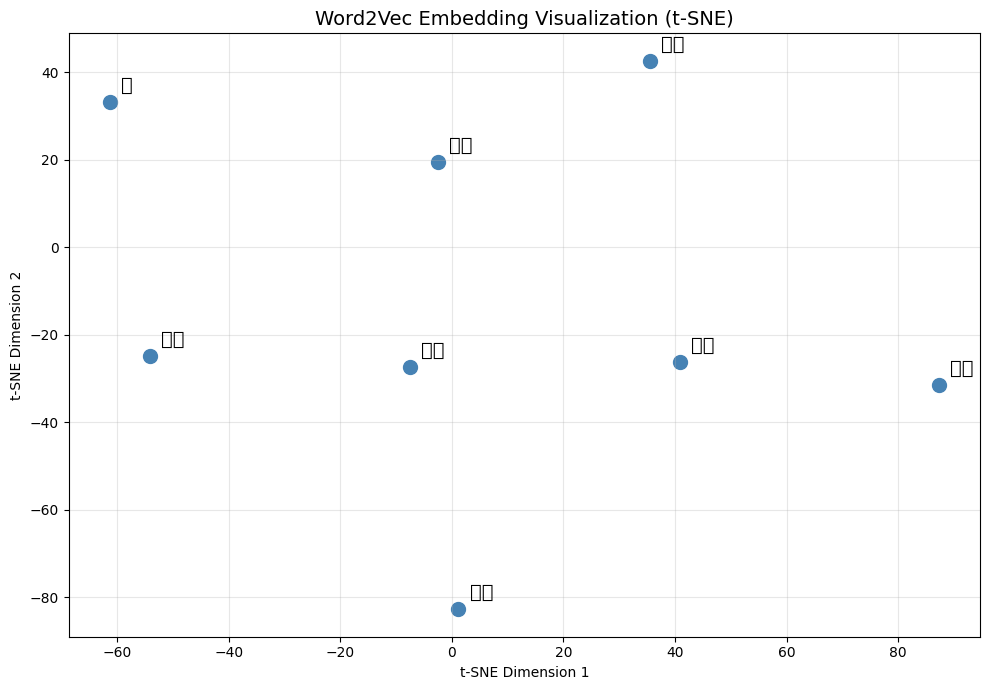


→ 의미적으로 유사한 단어들이 가까이 군집되는 것을 확인할 수 있습니다.


In [12]:
# === t-SNE 시각화 ===
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
# 한글 폰트가 있으면 아래 줄을 활성화하세요
# plt.rcParams['font.family'] = 'NanumGothic'

# 시각화할 단어 선택
words = ["왕", "여왕", "왕자", "공주", "남자", "여자", "소년", "소녀"]
word_vectors = np.array([model.wv[w] for w in words])

# t-SNE로 2차원 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(words)-1))
vectors_2d = tsne.fit_transform(word_vectors)

# 시각화
plt.figure(figsize=(10, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', s=100)

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=14, fontweight='bold',
                 xytext=(8, 8), textcoords='offset points')

plt.title('Word2Vec Embedding Visualization (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ 의미적으로 유사한 단어들이 가까이 군집되는 것을 확인할 수 있습니다.")

---
## 4️⃣ 현대 임베딩: 문맥 기반 임베딩 (Contextual Embeddings)

### Word2Vec의 한계

Word2Vec은 각 단어에 **하나의 고정된 벡터**를 부여합니다. 하지만 다의어를 처리할 수 없습니다:

- "배"가 과일인지 탈것인지 구분 불가
- "눈"이 신체 부위인지 날씨인지 구분 불가

### 해결책: 문맥 기반 임베딩

| 모델 | 특징 | 연도 |
|------|------|------|
| **ELMo** | 양방향 LSTM으로 문맥 반영 | 2018 |
| **BERT** | Transformer의 양방향 인코더로 문맥 반영 | 2018 |
| **GPT** | Transformer의 디코더로 좌→우 문맥 반영 | 2018~ |

```
Word2Vec:  "배" → 항상 동일한 벡터 [0.2, -0.1, ...]

BERT:      "나는 배를 먹었다"  → "배" = [과일 의미 벡터]
           "배를 타고 갔다"    → "배" = [탈것 의미 벡터]
```

> **핵심**: 현대 LLM(GPT-4, Claude, LLaMA 등)은 모두 Transformer 기반의 **문맥 기반 임베딩**을 사용합니다.

In [13]:
# === BERT의 문맥 기반 임베딩 맛보기 ===
from transformers import AutoModel, AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
model_bert = AutoModel.from_pretrained("bert-base-multilingual-cased")
model_bert.eval()

def get_word_embedding(sentence, target_word):
    """BERT로 특정 단어의 문맥 임베딩을 추출합니다."""
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model_bert(**inputs)
    
    # 토큰 확인
    tokens = tokenizer.tokenize(sentence)
    # 타겟 단어의 첫 번째 토큰 임베딩 반환 (+1은 [CLS] 토큰 때문)
    for i, token in enumerate(tokens):
        if target_word in token:
            return outputs.last_hidden_state[0, i+1, :].numpy()
    return outputs.last_hidden_state[0, 1, :].numpy()

# 같은 단어 "배"가 다른 문맥에서 다른 임베딩을 가짐
emb1 = get_word_embedding("나는 배를 먹었다", "배")
emb2 = get_word_embedding("배를 타고 바다로 갔다", "배")
emb3 = get_word_embedding("배가 너무 아프다", "배")

# 코사인 유사도 계산
from numpy.linalg import norm
cos = lambda a, b: np.dot(a, b) / (norm(a) * norm(b))

print("=== BERT 문맥 임베딩: '배'의 다양한 의미 ===")
print(f"  '배를 먹었다' vs '배를 타고': {cos(emb1, emb2):.4f}")
print(f"  '배를 먹었다' vs '배가 아프다': {cos(emb1, emb3):.4f}")
print(f"  '배를 타고'   vs '배가 아프다': {cos(emb2, emb3):.4f}")
print("\n  → 같은 '배'이지만 문맥에 따라 다른 임베딩 값을 가집니다!")

=== BERT 문맥 임베딩: '배'의 다양한 의미 ===
  '배를 먹었다' vs '배를 타고': 0.7472
  '배를 먹었다' vs '배가 아프다': 0.7322
  '배를 타고'   vs '배가 아프다': 0.7176

  → 같은 '배'이지만 문맥에 따라 다른 임베딩 값을 가집니다!


---
## 5️⃣ 실습: 한국어 텍스트 토큰화 + 임베딩 실습

한국어 텍스트를 직접 토큰화하고, Word2Vec 임베딩을 학습한 후 시각화하는 종합 실습입니다.

In [14]:
# === 실습용 한국어 텍스트 데이터 ===
korean_texts = [
    "인공지능은 기계가 인간의 지능을 모방하는 기술이다",
    "딥러닝은 인공 신경망을 활용한 기계 학습 방법이다",
    "자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술이다",
    "트랜스포머 모델은 어텐션 메커니즘을 사용한다",
    "대규모 언어 모델은 많은 데이터로 학습된다",
    "GPT는 생성형 사전 학습 트랜스포머이다",
    "BERT는 양방향 인코더 트랜스포머이다",
    "임베딩은 단어를 벡터 공간에 표현하는 방법이다",
    "토큰화는 텍스트를 작은 단위로 분리하는 과정이다",
    "어텐션은 입력의 중요한 부분에 집중하는 기법이다",
    "신경망은 뉴런으로 구성된 계산 모델이다",
    "기계 학습은 데이터에서 패턴을 학습하는 방법이다",
]

print(f"준비된 텍스트 수: {len(korean_texts)}")
for i, t in enumerate(korean_texts[:3]):
    print(f"  [{i}] {t}")
print("  ...")

준비된 텍스트 수: 12
  [0] 인공지능은 기계가 인간의 지능을 모방하는 기술이다
  [1] 딥러닝은 인공 신경망을 활용한 기계 학습 방법이다
  [2] 자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술이다
  ...


In [15]:
# === Step 1: 간단한 토큰화 (공백 기준) ===
tokenized_texts = [text.split() for text in korean_texts]

print("=== 공백 기준 토큰화 결과 ===")
for i, tokens in enumerate(tokenized_texts[:3]):
    print(f"  [{i}] {tokens}")

# 전체 어휘 확인
all_words = set(w for tokens in tokenized_texts for w in tokens)
print(f"\n전체 고유 단어 수: {len(all_words)}")

=== 공백 기준 토큰화 결과 ===
  [0] ['인공지능은', '기계가', '인간의', '지능을', '모방하는', '기술이다']
  [1] ['딥러닝은', '인공', '신경망을', '활용한', '기계', '학습', '방법이다']
  [2] ['자연어', '처리는', '컴퓨터가', '인간의', '언어를', '이해하는', '기술이다']

전체 고유 단어 수: 61


In [16]:
# === Step 2: Word2Vec 임베딩 학습 ===
model_ko = Word2Vec(
    tokenized_texts,
    vector_size=30,
    window=3,
    min_count=1,
    sg=1,
    epochs=300,
    seed=42
)

print("Word2Vec 학습 완료!")
print(f"어휘 크기: {len(model_ko.wv)}, 임베딩 차원: {model_ko.wv.vector_size}")

# 유사 단어 검색
print("\n=== '기술이다'와 유사한 단어 ===")
for word, score in model_ko.wv.most_similar("기술이다", topn=5):
    print(f"  {word}: {score:.4f}")

print("\n=== '트랜스포머'와 유사한 단어 ===")
for word, score in model_ko.wv.most_similar("트랜스포머이다", topn=5):
    print(f"  {word}: {score:.4f}")

Word2Vec 학습 완료!
어휘 크기: 61, 임베딩 차원: 30

=== '기술이다'와 유사한 단어 ===
  입력의: 0.8675
  방법이다: 0.8353
  인간의: 0.8345
  언어를: 0.8184
  기계: 0.8183

=== '트랜스포머'와 유사한 단어 ===
  컴퓨터가: 0.8279
  부분에: 0.8227
  활용한: 0.8215
  자연어: 0.8002
  작은: 0.7761


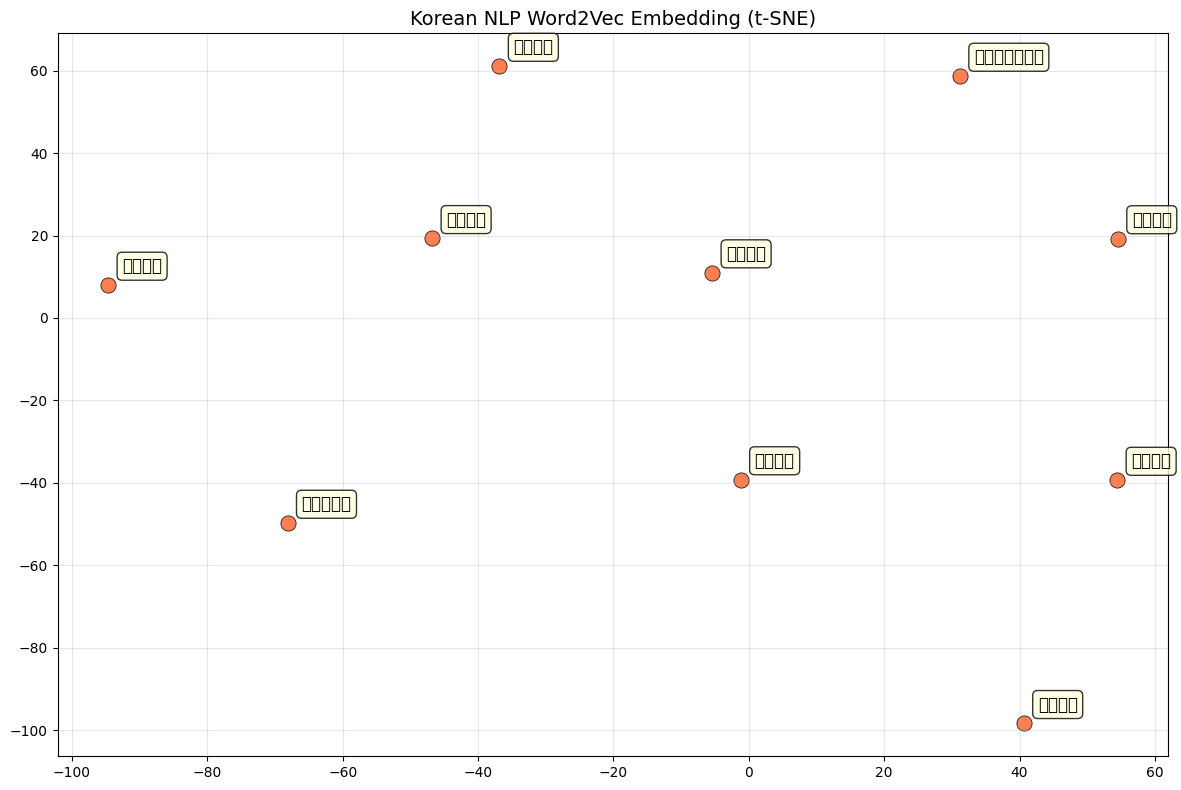

→ 의미적으로 유사한 단어들이 가까이 모이는 것을 관찰해 보세요.


In [17]:
# === Step 3: 임베딩 시각화 ===
# 시각화할 단어 선택 (주요 키워드)
target_words = [
    "인공지능은", "딥러닝은", "트랜스포머이다",
    "임베딩은", "토큰화는", "신경망은",
    "기술이다", "방법이다", "기법이다",
    "학습한다", "사용한다",
]

# 모델에 있는 단어만 필터링
target_words = [w for w in target_words if w in model_ko.wv]
vectors = np.array([model_ko.wv[w] for w in target_words])

# t-SNE 차원 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(target_words)-1))
vectors_2d = tsne.fit_transform(vectors)

# 시각화
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='coral', s=120, edgecolors='black', linewidths=0.5)

for i, word in enumerate(target_words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=12, fontweight='bold',
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.title('Korean NLP Word2Vec Embedding (t-SNE)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ 의미적으로 유사한 단어들이 가까이 모이는 것을 관찰해 보세요.")

In [18]:
# === Step 4: 토크나이저 비교 실험 ===
from transformers import AutoTokenizer

test_text = "대규모 언어 모델은 자연어 처리의 핵심 기술이다"

tokenizers_info = [
    ("BERT (Multilingual)", "bert-base-multilingual-cased"),
    ("GPT-2", "gpt2"),
]

print(f"입력 텍스트: \"{test_text}\"\n")
print(f"{'Tokenizer':<25} {'Token 수':<10} {'Tokens'}")
print("-" * 80)

for name, model_name in tokenizers_info:
    tok = AutoTokenizer.from_pretrained(model_name)
    tokens = tok.tokenize(test_text)
    print(f"{name:<25} {len(tokens):<10} {tokens}")

print("\n→ 한국어 텍스트에 대해 각 토크나이저의 토큰 수와 분리 방식이 다릅니다.")
print("→ 한국어 특화 모델은 더 적은 토큰으로 효율적으로 처리합니다.")

입력 텍스트: "대규모 언어 모델은 자연어 처리의 핵심 기술이다"

Tokenizer                 Token 수    Tokens
--------------------------------------------------------------------------------
BERT (Multilingual)       18         ['대', '##규', '##모', '언', '##어', '모', '##델', '##은', '자', '##연', '##어', '처', '##리의', '핵', '##심', '기', '##술', '##이다']
GPT-2                     57         ['ë', 'Į', 'Ģ', 'ê', '·', 'ľ', 'ë', 'ª', '¨', 'Ġì', 'ĸ', '¸', 'ì', 'ĸ', '´', 'Ġë', 'ª', '¨', 'ë', 'į', '¸', 'ìĿ', 'Ģ', 'Ġì', 'ŀ', 'Ĳ', 'ì', 'Ĺ', '°', 'ì', 'ĸ', '´', 'Ġì', '²', 'ĺ', 'ë', '¦', '¬', 'ìĿ', 'ĺ', 'Ġ', 'íķ', 'µ', 'ì', 'ĭ', '¬', 'Ġ', 'ê', '¸', '°', 'ì', 'Ī', 'ł', 'ìĿ', '´', 'ëĭ', '¤']

→ 한국어 텍스트에 대해 각 토크나이저의 토큰 수와 분리 방식이 다릅니다.
→ 한국어 특화 모델은 더 적은 토큰으로 효율적으로 처리합니다.


---
## 요약

| 개념 | 핵심 내용 |
|------|----------|
| **인코딩** | 문자 → 숫자 변환 (ASCII → Unicode/UTF-8) |
| **토큰화** | 텍스트 → 토큰 분리 (BPE, WordPiece, SentencePiece) |
| **Word2Vec** | 단어 → 밀집 벡터 (의미 유사도 표현 가능) |
| **문맥 임베딩** | 같은 단어도 문맥에 따라 다른 벡터 (BERT, GPT) |

### 다음 세션 예고

- 🔜 **Session 3**: 트랜스포머 아키텍처 - Attention, BERT, GPT 구조 비교

**© Copyright AIDENTIFY. All rights reserved.**